# Notebook 3 — Gradient Boosting (Member B)
Gradient Boosting giải bài toán tối ưu:
$$\min_{c_n, w_n} L\left(y,\; W_{n-1} + c_n w_n\right)$$

Thay vì tối ưu toàn cục (tốn kém), mỗi vòng lặp thêm một **weak learner** $w_n$ được train để fit vào **pseudo-residuals** – tức là âm của gradient hàm loss:
$$c_n w_n \approx -\eta \frac{\partial}{\partial w} L(W_{n-1})$$

Đây chính là **Gradient Descent trong không gian hàm số**.



## Các thư viện sử dụng

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings("ignore")
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score, average_precision_score, f1_score
)

from credit_utils.utils import preprocess_credit_card_data, load_creditcard_csv

RANDOM_STATE = 42
EARLY_STOP = 50
N_CV_FOLDS = 5
N_TRIALS = 100

colors = ['#FF5851', '#3d9dfc', '#d852fa', '#494a49', '#212121', '#ffffff', "#CBB736", '#03fc39']


# Load model có sẵn
Mục đích của đoạn code dưới đây là load lại các model đã lưu để sử dụng

In [ ]:
best_xgb = joblib.load('../models/xgb_boosted.pkl')
best_lgb = joblib.load('../models/lgb_boosted.pkl')

xgb_prob_tuned = np.load('../features/xgb_y_prob.npy')
lgb_prob_tuned = np.load('../features/lgb_y_prob.npy')
y_test         = np.load('../features/y_test_gb.npy')

results = pd.read_csv('../features/gb_metrics.csv', index_col='model')

xgb_imp = pd.read_csv('../features/xgb_feature_importance.csv')
lgb_imp = pd.read_csv('../features/lgb_feature_importance.csv')

print("Done!")
print(results.to_string())

Load xong!
                    ROC-AUC    PR-AUC        F1
model                                          
XGBoost Baseline   0.979625  0.888216  0.854167
LightGBM Baseline  0.978433  0.874001  0.869110
XGBoost (Optuna)   0.978862  0.876290  0.860104
LightGBM (Optuna)  0.978178  0.879367  0.857143


## Load và tiền xử lý dữ liệu

In [9]:
df = load_creditcard_csv()
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_credit_card_data(df)

1. Tách Features (X) và Target (y)...
2. Chia tập Train+Val / Test (80/20) với Stratify...
3. Chia tập Train / Val (70/10) với Stratify...
4. Áp dụng RobustScaler cho Time và Amount (fit trên train)...

Kích thước các tập:
  Train : (199364, 30) | Fraud rate: 0.173%
  Val   : (28481, 30)   | Fraud rate: 0.172%
  Test  : (56962, 30)  | Fraud rate: 0.172%


## Hàm đánh giá model

In [10]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)

    print(f"\n{'='*52}")
    print(f"  {model_name}")
    print(f"{'='*52}")

    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}")
    print(f"  F1-Score : {f1:.4f}")

    print(f"\n{'-'*52}")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

    return y_prob, {"model": model_name, "ROC-AUC": roc_auc, "PR-AUC": pr_auc, "F1": f1}

    

## Baseline models

**XGBoost Baseline**

In [11]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_baseline = xgb.XGBClassifier(
    n_estimators=1000,
    early_stopping_rounds=EARLY_STOP,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"XGBoost Baseline in the: {xgb_baseline.best_iteration}-th tree")
xgb_prob_base, xgb_metrics_base = evaluate_model(xgb_baseline, X_test, y_test, model_name="XGBoost Baseline")

scale_pos_weight = 576.87
XGBoost Baseline in the: 436-th tree

  XGBoost Baseline
  ROC-AUC  : 0.9796
  PR-AUC   : 0.8882
  F1-Score : 0.8542

----------------------------------------------------
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



**LightGBM Baseline**

In [12]:
lgb_baseline = lgb.LGBMClassifier(
    n_estimators=1000, 
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight={0: 1, 1: scale_pos_weight},
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1 # turn off logging
)

lgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)]
)

print(f"LightGBM Baseline in the: {lgb_baseline.best_iteration_}-th tree")
lgb_prob_base, lgb_metrics_base = evaluate_model(lgb_baseline, X_test, y_test, model_name="LightGBM Baseline")

LightGBM Baseline in the: 133-th tree

  LightGBM Baseline
  ROC-AUC  : 0.9784
  PR-AUC   : 0.8740
  F1-Score : 0.8691

----------------------------------------------------
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## Hyperparameter Tuning với Optuna

**XGBoost Objective**

In [13]:
def xgb_objective(trial):
    params = {
        'n_estimators'    : 1000,
        'early_stopping_rounds': EARLY_STOP,
        'max_depth'       : trial.suggest_int('max_depth', 6, 21),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.02, 0.09, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma'           : trial.suggest_float('gamma', 0, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 2.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 2.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric'     : 'aucpr',
        'random_state'    : RANDOM_STATE,
        'n_jobs'          : -1
    }

    cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )

        y_prob = model.predict_proba(X_fold_val)[:, 1]
        scores.append(average_precision_score(y_fold_val, y_prob))

    return np.mean(scores)

print("Tuning XGBoost...")
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest XGBoost PR-AUC: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

Tuning XGBoost...


Best trial: 85. Best value: 0.868336: 100%|██████████| 100/100 [13:47<00:00,  8.28s/it]


Best XGBoost PR-AUC: 0.8683
Best params: {'max_depth': 21, 'learning_rate': 0.08563755004530406, 'subsample': 0.9725370523137541, 'colsample_bytree': 0.6622511120793065, 'min_child_weight': 2, 'gamma': 0.028979620648257987, 'reg_alpha': 0.009850525849033677, 'reg_lambda': 3.7494092000378856e-07}


**LightGBM Objective**

In [28]:
def lgb_objective(trial):
    params = {
        'n_estimators'     : 1000,
        'max_depth'        : trial.suggest_int('max_depth', 6, 21),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.02, 0.09, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 2.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 2.0, log=True),
        'class_weight'     : {0: 1, 1: scale_pos_weight},
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }

    cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)]
        )

        y_prob = model.predict_proba(X_fold_val)[:, 1]
        scores.append(average_precision_score(y_fold_val, y_prob))

    return np.mean(scores)

print("Tuning LightGBM...")
lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest LightGBM PR-AUC: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

Tuning LightGBM...


Best trial: 61. Best value: 0.862856: 100%|██████████| 100/100 [12:42<00:00,  7.63s/it]


Best LightGBM PR-AUC: 0.8629
Best params: {'max_depth': 9, 'learning_rate': 0.02893469689043264, 'num_leaves': 95, 'subsample': 0.7060778222616031, 'colsample_bytree': 0.5013874145765683, 'min_child_samples': 71, 'reg_alpha': 3.065825087108324e-06, 'reg_lambda': 1.7509871791497564}


## Đánh giá sau Tuning
Phần này chúng ta sẽ train lại với best parameter.

In [29]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_xgb = xgb.XGBClassifier(
    **xgb_study.best_params,
    n_estimators=1000,
    early_stopping_rounds=EARLY_STOP,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb.fit(
    X_trainval, y_trainval,
    eval_set=[(X_test, y_test)],
    verbose=False
)

best_lgb = lgb.LGBMClassifier(
    **lgb_study.best_params,
    n_estimators=1000,
    class_weight={0: 1, 1: scale_pos_weight},
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

best_lgb.fit(
    X_trainval, y_trainval,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)]
)

xgb_prob_tuned, xgb_metrics_tuned = evaluate_model(best_xgb, X_test, y_test, "XGBoost (Optuna)")
lgb_prob_tuned, lgb_metrics_tuned = evaluate_model(best_lgb, X_test, y_test, "LightGBM (Optuna)")


  XGBoost (Optuna)
  ROC-AUC  : 0.9807
  PR-AUC   : 0.8784
  F1-Score : 0.8586

----------------------------------------------------
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962


  LightGBM (Optuna)
  ROC-AUC  : 0.9801
  PR-AUC   : 0.8820
  F1-Score : 0.8615

----------------------------------------------------
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



**Optuna Visualization**

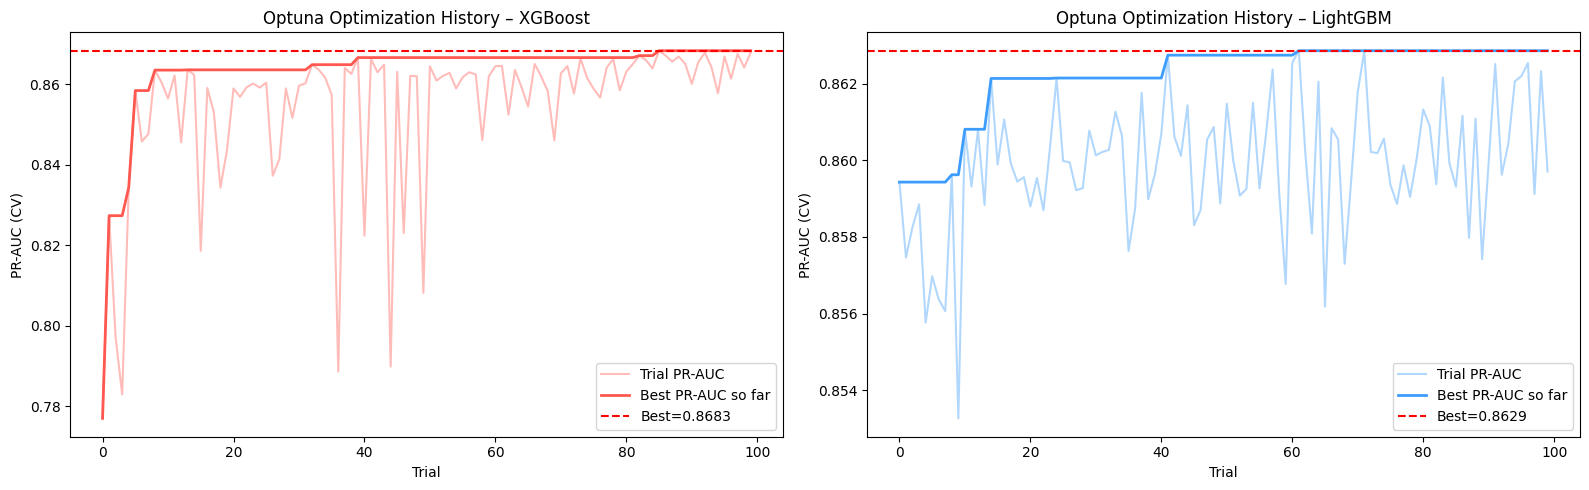

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, study, name, color in [
    (axes[0], xgb_study, "XGBoost", colors[0]),
    (axes[1], lgb_study, "LightGBM", colors[1])
]:
    trials_df = study.trials_dataframe()
    ax.plot(trials_df.index, trials_df['value'], alpha=0.4, color=color, label='Trial PR-AUC')
    ax.plot(trials_df.index, trials_df['value'].cummax(), color=color, linewidth=2, label='Best PR-AUC so far')
    ax.axhline(
        study.best_value, color='red',
        linestyle='--',
        label=f'Best={study.best_value:.4f}'
    )
    ax.set_xlabel('Trial'); ax.set_ylabel('PR-AUC (CV)')
    ax.set_title(f'Optuna Optimization History – {name}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Hyperparameter importance**

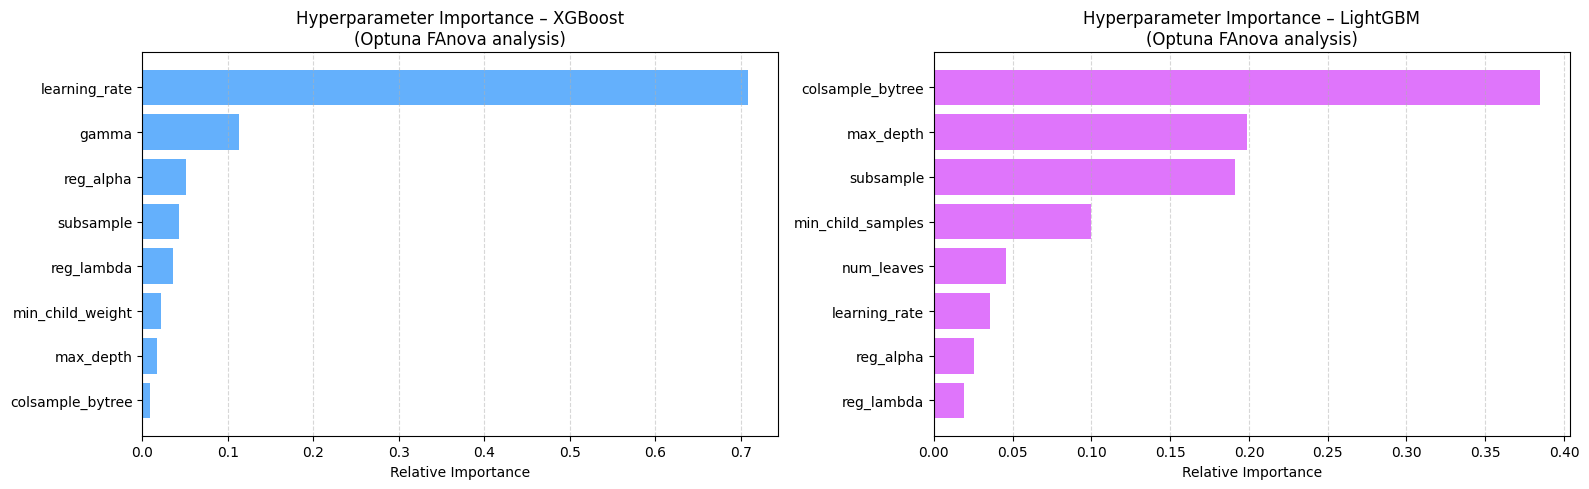

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, study, name in [
    (axes[0], xgb_study, 'XGBoost'),
    (axes[1], lgb_study, 'LightGBM')
]:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values = list(importances.values())
    ax.barh(params[::-1], values[::-1], color=colors[1] if 'XG' in name else colors[2], alpha=0.8)
    ax.set_xlabel('Relative Importance')
    ax.set_title(f'Hyperparameter Importance – {name}\n(Optuna FAnova analysis)')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Look at these graphs, we can see which parameter to fix to make the model work efficiently.

## Feature Importance

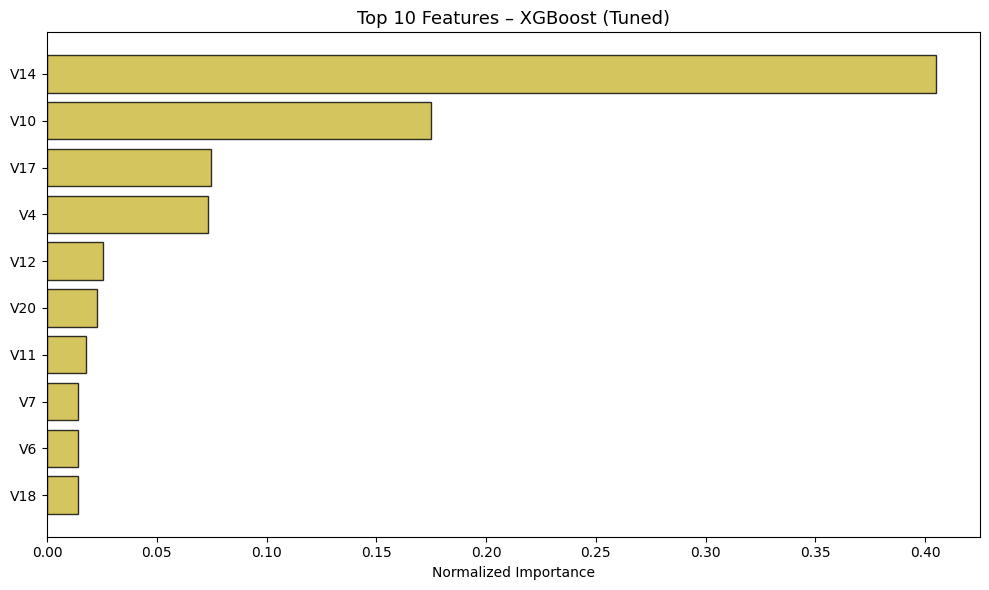

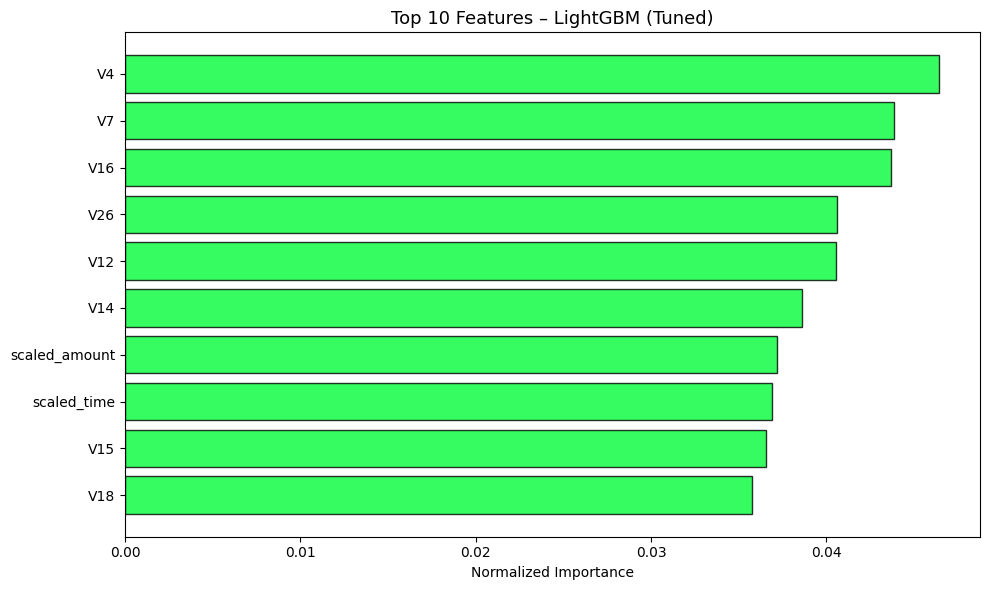

In [32]:
def plot_feature_importances(model, feature_names, model_name, color, top_n=20):
    importance = model.feature_importances_
    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    df_imp['importances_normalized'] = df_imp['importance'] / df_imp['importance'].sum()
    
    df_top = df_imp.head(top_n)
    plt.figure(figsize=(10, 6))
    ax = plt.subplot()
    ax.barh(
        list(reversed(list(df_top.index))),
        df_top['importances_normalized'],
        align='center',
        color=color,
        edgecolor='k',
        alpha=0.8
    )
    ax.set_yticks(list(reversed(list(df_top.index))))
    ax.set_yticklabels(df_top['feature'])
    plt.xlabel('Normalized Importance')
    plt.title(f'Top {top_n} Features – {model_name}', fontsize=13)
    plt.tight_layout()
    plt.show()
    return df_imp

feature_names = [col for col in df.columns if col not in ['Class', 'Time', 'Amount']] + ['scaled_amount', 'scaled_time']
xgb_imp = plot_feature_importances(best_xgb, feature_names, 'XGBoost (Tuned)', colors[6], 10)
lgb_imp = plot_feature_importances(best_lgb, feature_names, 'LightGBM (Tuned)', colors[7], 10)

**So sánh TOP10 features**

In [33]:
top10_xgb = set(xgb_imp.head(10)['feature'])
top10_lgb = set(lgb_imp.head(10)['feature'])
common    = top10_xgb & top10_lgb

print(f"Top 10 XGBoost  : {sorted(top10_xgb)}")
print(f"Top 10 LightGBM : {sorted(top10_lgb)}")
print(f"Common Features : {sorted(common)} ({len(common)}/10 features)")
print("\nFeatures appear in both models top 10 are likely to be more reliable indicators of fraud, so they deserve special attention.")

Top 10 XGBoost  : ['V10', 'V11', 'V12', 'V14', 'V17', 'V18', 'V20', 'V4', 'V6', 'V7']
Top 10 LightGBM : ['V12', 'V14', 'V15', 'V16', 'V18', 'V26', 'V4', 'V7', 'scaled_amount', 'scaled_time']
Common Features : ['V12', 'V14', 'V18', 'V4', 'V7'] (5/10 features)

Features appear in both models top 10 are likely to be more reliable indicators of fraud, so they deserve special attention.


## Save model and artifacts

In [34]:
os.makedirs('../models', exist_ok=True)
os.makedirs('../features', exist_ok=True)

joblib.dump(best_xgb, '../models/xgb_boosted.pkl')
joblib.dump(best_lgb, '../models/lgb_boosted.pkl')

np.save('../features/xgb_y_prob.npy', xgb_prob_tuned)
np.save('../features/lgb_y_prob.npy', lgb_prob_tuned)
np.save('../features/y_test_gb.npy', y_test)

results = pd.DataFrame([
    xgb_metrics_base,
    lgb_metrics_base,
    xgb_metrics_tuned,
    lgb_metrics_tuned
]).set_index('model')
results.to_csv('../features/gb_metrics.csv')

xgb_imp.to_csv('../features/xgb_feature_importance.csv', index=False)
lgb_imp.to_csv('../features/lgb_feature_importance.csv', index=False)

print("Saved the following files:")
print("models/xgboost_best.pkl, models/lightgbm_best.pkl")
print("features/xgb_y_prob.npy, features/lgb_y_prob.npy, features/y_test_gb.npy")
print("features/gb_metrics.csv")
print("features/xgb_feature_importance.csv, features/lgb_feature_importance.csv")
print(results.to_string())


Saved the following files:
models/xgboost_best.pkl, models/lightgbm_best.pkl
features/xgb_y_prob.npy, features/lgb_y_prob.npy, features/y_test_gb.npy
features/gb_metrics.csv
features/xgb_feature_importance.csv, features/lgb_feature_importance.csv
                    ROC-AUC    PR-AUC        F1
model                                          
XGBoost Baseline   0.979625  0.888216  0.854167
LightGBM Baseline  0.978433  0.874001  0.869110
XGBoost (Optuna)   0.980739  0.878367  0.858639
LightGBM (Optuna)  0.980121  0.881978  0.861538
